In [42]:
import os
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

In [57]:
image_folder = "/Users/ann/Desktop/ML/ML2/black_and_white_photo_colorization/Images"

cities = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]
data = []

for city in cities:
    city_path = os.path.join(image_folder, city)
    for file in os.listdir(city_path):
        if file.lower().endswith(".jpg"):
            data.append(os.path.join(city_path, file))

print(f"Total JPG images collected: {len(data)}")
random.shuffle(data)
data_subset = data[:80000]

Total JPG images collected: 119043


In [58]:
train_paths, test_paths = train_test_split(data_subset, test_size=0.2, random_state=42)


In [59]:
class ColorizationDataGenerator(Sequence):
    def __init__(self, image_paths, batch_size=8, img_size=(128, 128)):
        self.image_paths = image_paths
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        x_batch = []
        y_batch = []

        for path in batch_paths:
            img = Image.open(path).convert('RGB').resize(self.img_size)
            img_array = np.array(img) / 255.0  

            
            gray_img = img.convert('L')
            gray_array = np.array(gray_img) / 255.0
            gray_array = np.expand_dims(gray_array, axis=-1) 

            
            x_batch.append(gray_array)
            y_batch.append(img_array)

        
        return np.array(x_batch, dtype=np.float32), np.array(y_batch, dtype=np.float32)



 

In [60]:
batch_size = 8
train_gen = ColorizationDataGenerator(train_paths, batch_size=batch_size, img_size=(128, 128))
test_gen  = ColorizationDataGenerator(test_paths, batch_size=batch_size, img_size=(128, 128))


x_batch, y_batch = train_gen[0]

print("X batch shape:", x_batch.shape) 
print("Y batch shape:", y_batch.shape)

X batch shape: (8, 128, 128, 1)
Y batch shape: (8, 128, 128, 3)


In [61]:
def build_unet(input_shape=(128, 128,1)):
    inp = Input(input_shape)

    c1 = Conv2D(64, 3, activation='relu', padding='same')(inp)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D(2)(c2)

    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D(2)(c3)

    c4 = Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(c4)

    u5 = UpSampling2D(2)(c4)
    u5 = Concatenate()([u5, c3])
    c5 = Conv2D(256, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(256, 3, activation='relu', padding='same')(c5)

    u6 = UpSampling2D(2)(c5)
    u6 = Concatenate()([u6, c2])
    c6 = Conv2D(128, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(128, 3, activation='relu', padding='same')(c6)

    u7 = UpSampling2D(2)(c6)
    u7 = Concatenate()([u7, c1])
    c7 = Conv2D(64, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(64, 3, activation='relu', padding='same')(c7)

    outputs = Conv2D(3, 1, activation='sigmoid')(c7) 

    model = Model(inp, outputs)
    return model


model = build_unet(input_shape=(128, 128,1))
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 128, 128,  │        640 │ input_layer_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 128, 128,  │     36,928 │ conv2d_105[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 64, 64,    │          0 │ conv2d_106[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 64, 64,    │     73,856 │ max_pooling2d_21… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 64, 64,    │    147,584 │ conv2d_107[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 32, 32,    │          0 │ conv2d_108[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 32, 32,    │    295,168 │ max_pooling2d_22… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 32, 32,    │    590,080 │ conv2d_109[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 16, 16,    │          0 │ conv2d_110[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_23… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 16, 16,    │  2,359,808 │ conv2d_111[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_21    │ (None, 32, 32,    │          0 │ conv2d_112[0][0]  │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_21      │ (None, 32, 32,    │          0 │ up_sampling2d_21… │
│ (Concatenate)       │ 768)              │            │ conv2d_110[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_113 (Conv2D) │ (None, 32, 32,    │  1,769,728 │ concatenate_21[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_114 (Conv2D) │ (None, 32, 32,    │    590,080 │ conv2d_113[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_22    │ (None, 64, 64,    │          0 │ conv2d_114[0][0]

 Total params: 7,781,891 (29.69 MB)

 Trainable params: 7,781,891 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
epochs = 1
batch_size = 8 

model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=epochs,
    verbose=1
)

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 12596s 2s/step - loss: 0.0014 - val_loss: 0.0014


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


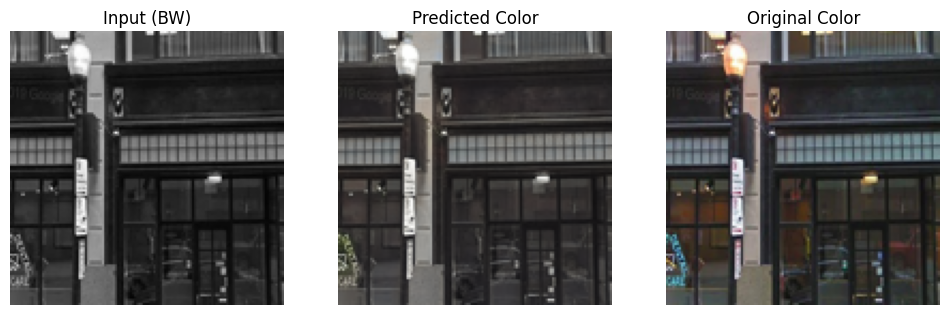

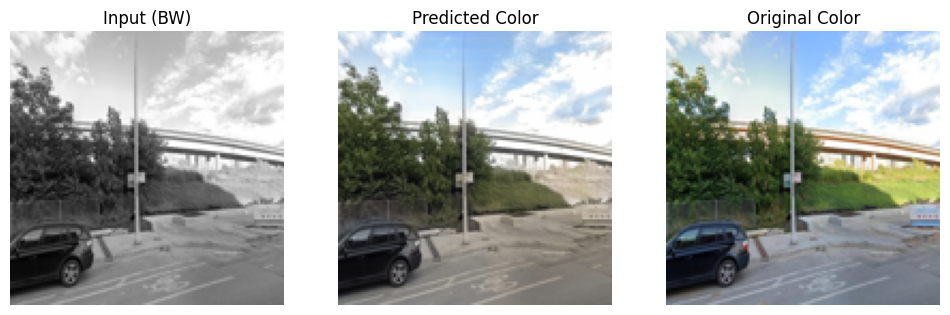

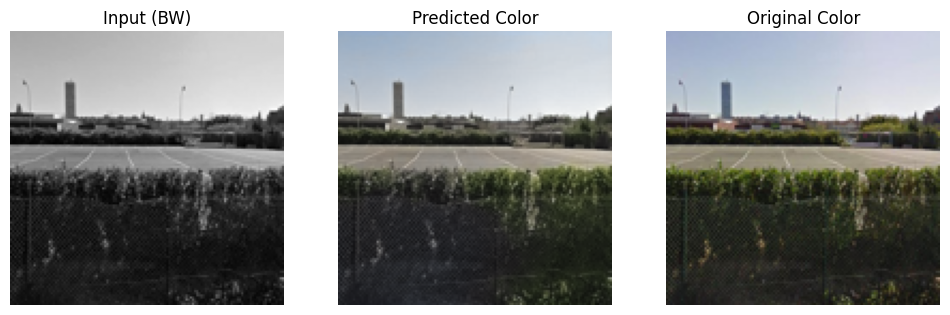

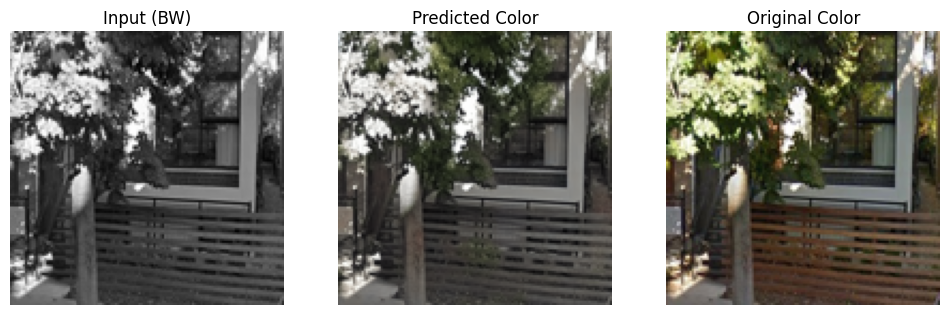

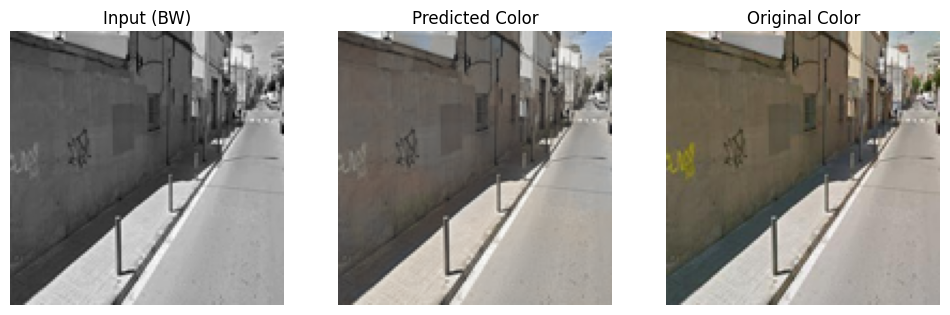

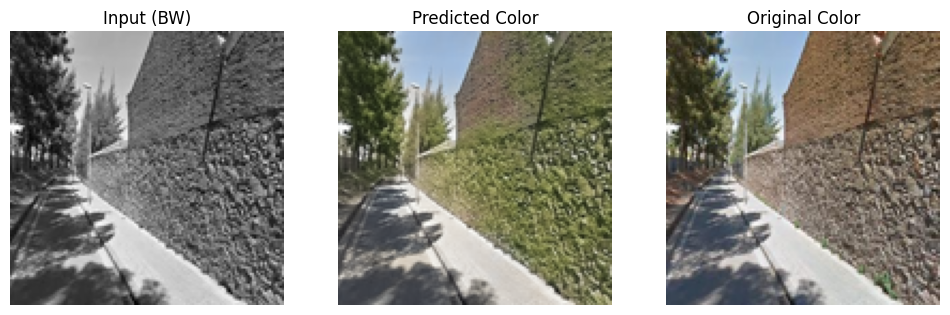

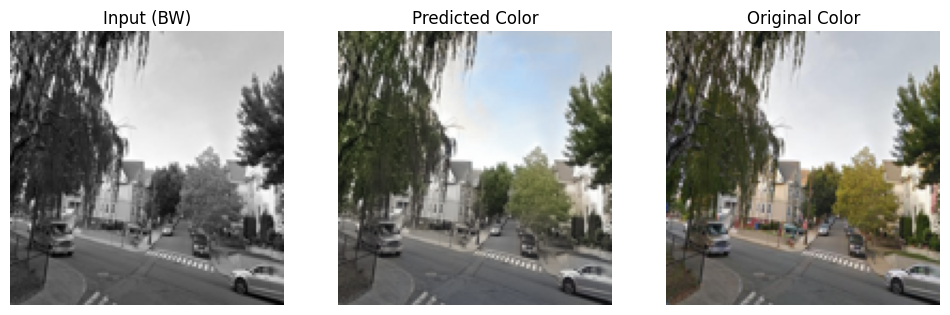

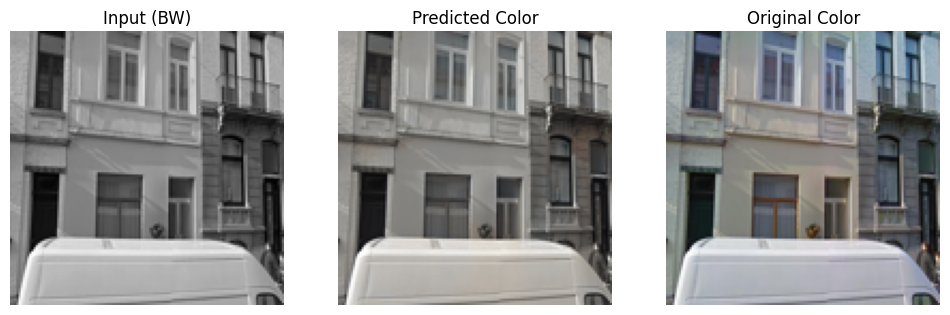

In [89]:
x_test, y_test = test_gen[0]
pred = model.predict(x_test)

for i in range(8):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Input (BW)")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(pred[i])
    plt.title("Predicted Color")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(y_test[i])
    plt.title("Original Color")
    plt.axis('off')
    
    plt.show()

In [86]:
model.save("Black_and_White_Image_Colorization_8Epochs.keras")